# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


MCP neuron can only handle binary classification, such that solution for linearly separable problems are possible through it.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###

  # Create a new array to put all the prediction let's name that a state_neuron.
  state_neuron=[]

  for i in range(len(X1)):
    #sum of inputs for the current index
        z = X1[i] + X2[i]

  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
        if z >= T:
            # 3. Action (indented twice)
            state_neuron.append(1)
        else:
            # 3. Action (indented twice)
            state_neuron.append(0)
  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron=[]

    # Perform an element wise addition of two input arrays stored in a new array(list):
    for i in range(len(X1)):
        # Calculate the sum for the current index
        z = X1[i] + X2[i]
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    if z >= T:
            state_neuron.append(1)
    else:
          state_neuron.append(0)
    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [1]


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/sem6/week3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

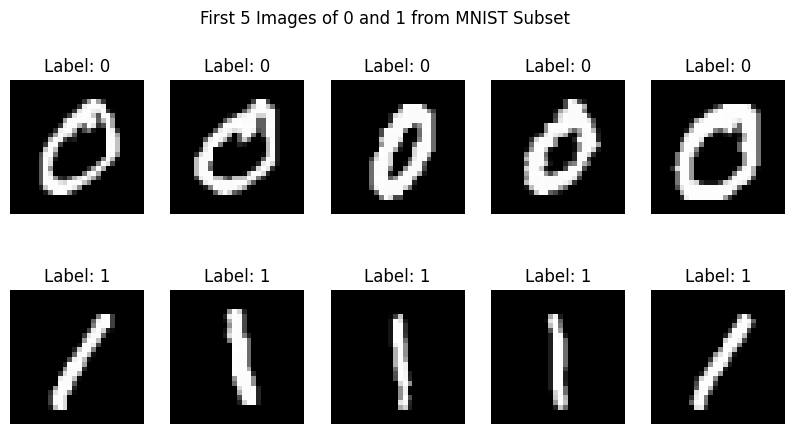

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    # np.where returns 1 if the condition is met, and 0 otherwise
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    n_samples = X.shape[0]

    for epoch in range(epochs):
        accuracy = 0
        for i in range(n_samples):
            # Calculate the linear combination (z = Xw + b)
            linear_output = np.dot(X[i], weights) + bias

            # Activation function (Step function: 1 if >= 0, else 0)
            y_pred = 1 if linear_output >= 0 else 0

            # Check if prediction is correct
            if y_pred == y[i]:
                accuracy += 1
            else:
                # Update rule: W = W + learning_rate * (y_true - y_pred) * X
                update = learning_rate * (y[i] - y_pred)
                weights += update * X[i]
                bias += update

        # Optional: Stop early if 100% accuracy is reached
        if accuracy == n_samples:
            break

    return weights, bias, accuracy

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  12665


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/sem6/week3/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


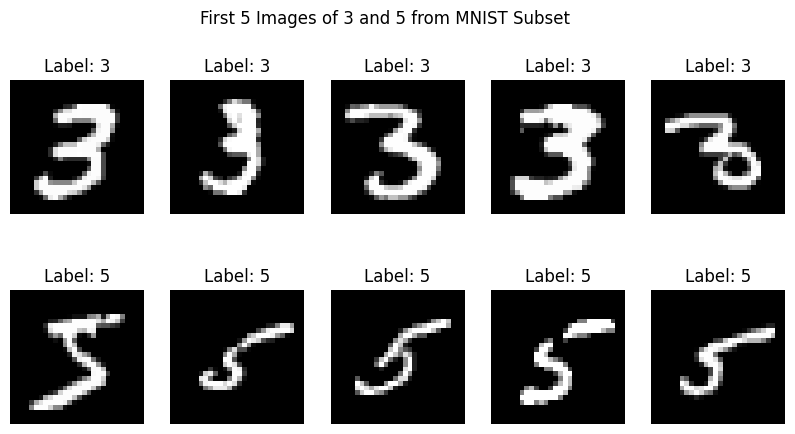

In [ ]:
# 1. Correct the filtering
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# 2. Update the check to look at the new variables
if len(images_3) < 5 or len(images_5) < 5:
    print(f"Error: Not enough images. Found {len(images_3)} 3s and {len(images_5)} 5s.")
else:
    for i in range(5):
        # 3. Plot digit 3 (Top Row)
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        # 4. Plot digit 5 (Bottom Row)
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [ ]:
# Initialize weights and bias for 3 vs 5 classification
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [ ]:
# Train the perceptron for 3 vs 5 classification
# Note: The y labels in the dataset are 3 and 5. The perceptron expects 0 and 1.
# So, we need to map the labels: 3 -> 0 and 5 -> 1 for training.
y_mapped = np.where(y == 3, 0, 1)

weights_3_5, bias_3_5, accuracy_3_5 = train_perceptron(X, y_mapped, weights.copy(), bias, learning_rate, epochs)

# Evaluate the model using the new function
print(f"The Final Accuracy for 3 vs 5 classification is: {accuracy_3_5 / len(y_mapped):.4f}")

The Final Accuracy for 3 vs 5 classification is: 1.0000


In [ ]:
# Map original labels to binary (3 becomes 0, 5 becomes 1)
y_mapped = np.where(y == 3, 0, 1)

# Train using the mapped labels
weights_3_5, bias_3_5, accuracy_count = train_perceptron(X, y_mapped, weights.copy(), bias, learning_rate, epochs)

# Get predictions (binary: 0 or 1)
linear_output = np.dot(X, weights_3_5) + bias_3_5
y_pred_binary = np.where(linear_output >= 0, 1, 0)

# Calculate real accuracy (compare binary to binary)
final_accuracy = np.mean(y_pred_binary == y_mapped)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Identify misclassified indices
misclassified_idx = np.where(y_pred_binary != y_mapped)[0]
print(f"Number of misclassified images: {len(misclassified_idx)}")

# Visualize (if there are errors)
if len(misclassified_idx) > 0:
    plt.figure(figsize=(12, 5))
    num_to_show = min(len(misclassified_idx), 10)

    for i in range(num_to_show):
        idx = misclassified_idx[i]
        plt.subplot(2, 5, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")

        # Map back to 3 and 5 just for the title
        actual = y[idx]
        pred = 3 if y_pred_binary[idx] == 0 else 5

        plt.title(f"P: {pred}, T: {actual}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Perfect classification! No errors to show.")

Final Accuracy: 1.0000
Number of misclassified images: 0
Perfect classification! No errors to show.
